# Decision Trees, From Scratch\n\nA decision tree asks one question at a time: is this feature above or below some threshold? Each question is picked greedily — whichever split makes the two resulting groups as pure as possible, measured by Gini impurity — and the process repeats recursively on each half until a stopping rule kicks in.\n\nNo gradients, no iterative optimization, no backprop. This notebook implements a CART-style binary classification tree from scratch in numpy — no `sklearn.tree.DecisionTreeClassifier` — on a checkerboard dataset: four overlapping blobs arranged so that, like XOR, no single straight line separates the two classes. A tree solves it completely differently from the neural network in the backprop notebook: instead of bending the space with nonlinear activations, it carves the space up with a sequence of axis-aligned cuts.\n\nThe companion interactive version — same math, a depth slider driving the tree live — lives at `web/`.

train: 70 test: 30


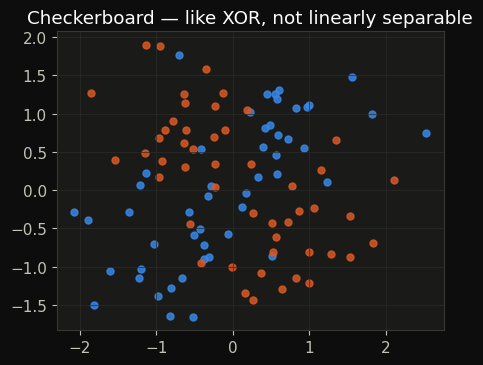

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

CLASS_COLORS = ["#3987e5", "#d95926"]


def make_checkerboard(per_quadrant=25, seed=3, spread=0.55):
    rng = np.random.default_rng(seed)
    quadrants = [(0.7, 0.7, 0), (-0.7, -0.7, 0), (0.7, -0.7, 1), (-0.7, 0.7, 1)]
    points, labels = [], []
    for cx, cy, label in quadrants:
        pts = np.column_stack([
            cx + rng.normal(0, spread, per_quadrant),
            cy + rng.normal(0, spread, per_quadrant),
        ])
        points.append(pts)
        labels.append(np.full(per_quadrant, label))
    X = np.vstack(points)
    y = np.concatenate(labels)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


X, y = make_checkerboard()
split = int(len(X) * 0.7)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]
print("train:", len(X_train), "test:", len(X_test))

fig, ax = plt.subplots(figsize=(5, 5))
for cls in (0, 1):
    ax.scatter(*X[y == cls].T, color=CLASS_COLORS[cls], s=25, alpha=0.85)
ax.set_aspect("equal")
ax.set_title("Checkerboard — like XOR, not linearly separable")
plt.show()

## Gini impurity and the greedy split

$$\text{Gini}(S) = 1 - \sum_c p_c^2$$

$p_c$ is the fraction of group $S$ belonging to class $c$. A pure group (every point the same class) has Gini 0; a 50/50 split of two classes has Gini 0.5 — the maximum for binary labels. To score a *split* of $S$ into $S_{\text{left}}$ and $S_{\text{right}}$, weight each half's impurity by its size:

$$\text{Gini}_{\text{split}} = \frac{|S_{\text{left}}|}{|S|}\text{Gini}(S_{\text{left}}) + \frac{|S_{\text{right}}|}{|S|}\text{Gini}(S_{\text{right}})$$

The greedy algorithm tries every candidate threshold on every feature and keeps whichever split minimizes this weighted impurity.

In [2]:
def gini_impurity(labels):
    if len(labels) == 0:
        return 0.0
    p1 = np.mean(labels == 1)
    p0 = 1 - p1
    return 1 - p0**2 - p1**2


def best_split(X, y):
    best = None
    for feature_index in (0, 1):
        order = np.argsort(X[:, feature_index])
        values = X[order, feature_index]
        for i in range(1, len(values)):
            if values[i] == values[i - 1]:
                continue
            threshold = (values[i] + values[i - 1]) / 2
            left_mask = X[:, feature_index] < threshold
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            weighted = (
                left_mask.sum() * gini_impurity(y[left_mask])
                + right_mask.sum() * gini_impurity(y[right_mask])
            ) / len(y)
            if best is None or weighted < best["weighted"]:
                best = {"feature_index": feature_index, "threshold": threshold, "weighted": weighted}
    return best


def majority_label(y):
    return int(np.sum(y == 1) >= len(y) - np.sum(y == 1))


def build_tree(X, y, max_depth, depth=0):
    if depth >= max_depth or gini_impurity(y) == 0 or len(y) < 4:
        return {"type": "leaf", "prediction": majority_label(y)}

    split = best_split(X, y)
    if split is None:
        return {"type": "leaf", "prediction": majority_label(y)}

    mask = X[:, split["feature_index"]] < split["threshold"]
    return {
        "type": "split",
        "feature_index": split["feature_index"],
        "threshold": split["threshold"],
        "left": build_tree(X[mask], y[mask], max_depth, depth + 1),
        "right": build_tree(X[~mask], y[~mask], max_depth, depth + 1),
    }


def predict_one(node, point):
    if node["type"] == "leaf":
        return node["prediction"]
    value = point[node["feature_index"]]
    branch = node["left"] if value < node["threshold"] else node["right"]
    return predict_one(branch, point)


def predict(node, X):
    return np.array([predict_one(node, p) for p in X])


def accuracy(node, X, y):
    return float(np.mean(predict(node, X) == y))

## The decision surface at increasing depth

Every panel is the same greedy algorithm, stopped at a different depth. Filled markers are training points; hollow markers are the held-out test set, never used to pick a split.

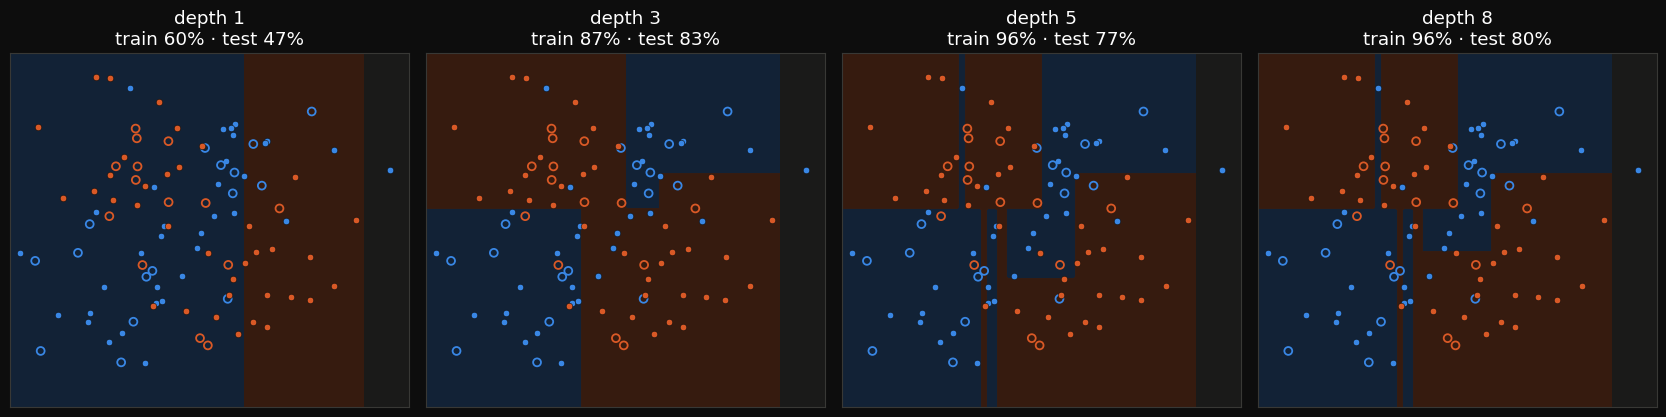

In [3]:
grid_n = 200
g = np.linspace(-2.2, 2.2, grid_n)
GX, GY = np.meshgrid(g, g)
grid_points = np.stack([GX.ravel(), GY.ravel()], axis=1)

depths_to_show = [1, 3, 5, 8]
fig, axes = plt.subplots(1, len(depths_to_show), figsize=(4.2 * len(depths_to_show), 4.5))

for ax, depth in zip(axes, depths_to_show):
    tree = build_tree(X_train, y_train, depth)
    Z = predict(tree, grid_points).reshape(grid_n, grid_n)
    ax.contourf(GX, GY, Z, levels=[-0.5, 0.5, 1.5], colors=["#12233a", "#3a1c0e"], alpha=0.9)

    for cls in (0, 1):
        ax.scatter(*X_train[y_train == cls].T, color=CLASS_COLORS[cls], s=22, edgecolor="#0d0d0d", linewidth=0.4)
        ax.scatter(*X_test[y_test == cls].T, facecolor="none", edgecolor=CLASS_COLORS[cls], s=32, linewidth=1.3)

    train_acc = accuracy(tree, X_train, y_train)
    test_acc = accuracy(tree, X_test, y_test)
    ax.set_title(f"depth {depth}\ntrain {train_acc:.0%} · test {test_acc:.0%}")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

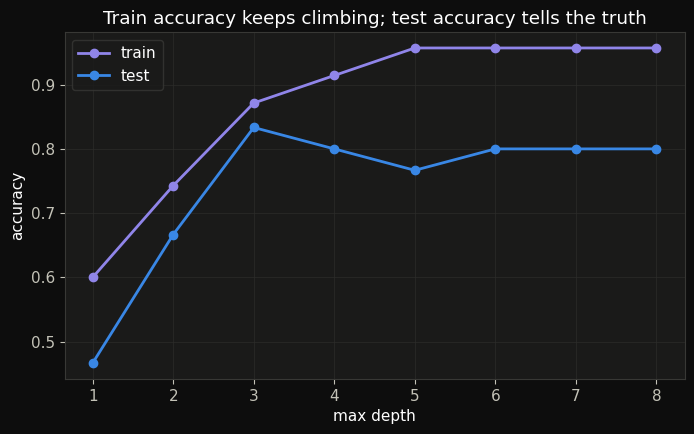

best test accuracy at depth 3: 83.3%
depth 8 test accuracy: 80.0% (train: 95.7%)


In [4]:
max_depths = range(1, 9)
train_accs, test_accs = [], []
for d in max_depths:
    tree = build_tree(X_train, y_train, d)
    train_accs.append(accuracy(tree, X_train, y_train))
    test_accs.append(accuracy(tree, X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(max_depths), train_accs, color="#9085e9", linewidth=2, marker="o", label="train")
ax.plot(list(max_depths), test_accs, color="#3987e5", linewidth=2, marker="o", label="test")
ax.set_xlabel("max depth")
ax.set_ylabel("accuracy")
ax.set_title("Train accuracy keeps climbing; test accuracy tells the truth")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

best_depth = int(np.argmax(test_accs)) + 1
print(f"best test accuracy at depth {best_depth}: {max(test_accs):.1%}")
print(f"depth 8 test accuracy: {test_accs[-1]:.1%} (train: {train_accs[-1]:.1%})")

## Takeaways

- A decision tree's only real ingredient is the split criterion — greedily minimize weighted Gini impurity, recursively, and the rest follows.
- Splits are always axis-aligned, so the decision surface is always made of rectangles — visibly different from a neural network's smooth curved boundary or an SVM's kernel-shaped one, even when solving the same problem.
- Train accuracy is not a trustworthy stopping signal: it climbs toward 100% simply by carving out smaller and smaller regions to fit individual noisy points, regardless of whether those splits generalize.
- Depth is a direct, single-knob complexity control. Too shallow underfits (the tree can't express the checkerboard shape yet); too deep overfits (it starts fitting noise). The held-out test set is what actually reveals where that line is — the training data alone can't tell you.